In [76]:
%pip install -q matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [77]:
x1 = [10,8,13,9,11,14,6,4,12,7,5]
y1 = [8.04,6.95,7.58,8.81,8.33,9.96,7.24,4.26,10.84,4.82,5.68] 

x2 = [10,8,13,9,11,14,6,4,12,7,5]
y2 = [9.14,8.14,8.47,8.77,9.26,8.10,6.13,3.10,9.13,7.26,4.74]

x3 = [8,8,8,8,8,8,8,8,8,8,19]
y3 = [6.58,5.76,7.71,8.84,8.47,7.04,5.25,5.56,7.91,6.89,12.50]

In [78]:
def media(vetor): return sum(vetor) / len(vetor)

def calcula_produto_ambos(vetX, vetY):
    # parte de cima 
    produto_ambos = 0
    for i in range(len(vetX)):
        x = vetX[i]
        y = vetY[i]

        produto_ambos = produto_ambos + ((x - media(vetX)) * (y - media(vetY)))

    return produto_ambos

def calcula_produto(vet):
    produto = 0
    for i in range(len(vet)):
        x = vet[i]

        produto = produto + ((x - media(vet)) ** 2)

    return produto

In [79]:
from math import sqrt


def correlacao(vetX, vetY):
    # parte de cima
    produto_ambos = calcula_produto_ambos(vetX, vetY)

    # parte de baixo 
    produto_x = calcula_produto(vetX)
    produto_y = calcula_produto(vetY)
    raiz_quadrada_produtos = sqrt(produto_x * produto_y)

    return produto_ambos / raiz_quadrada_produtos

In [80]:
def betaUm(vetX, vetY):
    return calcula_produto_ambos(vetX, vetY) / calcula_produto(vetX)

def betaZero(vetX, vetY, betaUm):
    return media(vetY) - (betaUm * media(vetX))

def regressao(vetX, vetY, varIndependente):
    return betaZero(vetX, vetY, betaUm(vetX, vetY)) + (betaUm(vetX, vetY) * varIndependente)

In [81]:
print("c", correlacao(x1, y1))
print("b1", betaUm(x1, y1))
print("b0", betaZero(x1, y1, betaUm(x1, y1)))

print("=" * 10)

print("c", correlacao(x2, y2))
print("b1", betaUm(x2, y2))
print("b0", betaZero(x2, y2, betaUm(x2, y2)))

print("=" * 10)

print("c", correlacao(x3, y3))
print("b1", betaUm(x3, y3))
print("b0", betaZero(x3, y3, betaUm(x3, y3)))

c 0.81642051634484
b1 0.5000909090909091
b0 3.0000909090909085
c 0.8061168716933017
b1 0.4901818181818182
b0 3.0647272727272714
c 0.8165214368885029
b1 0.4999090909090909
b0 3.0017272727272726


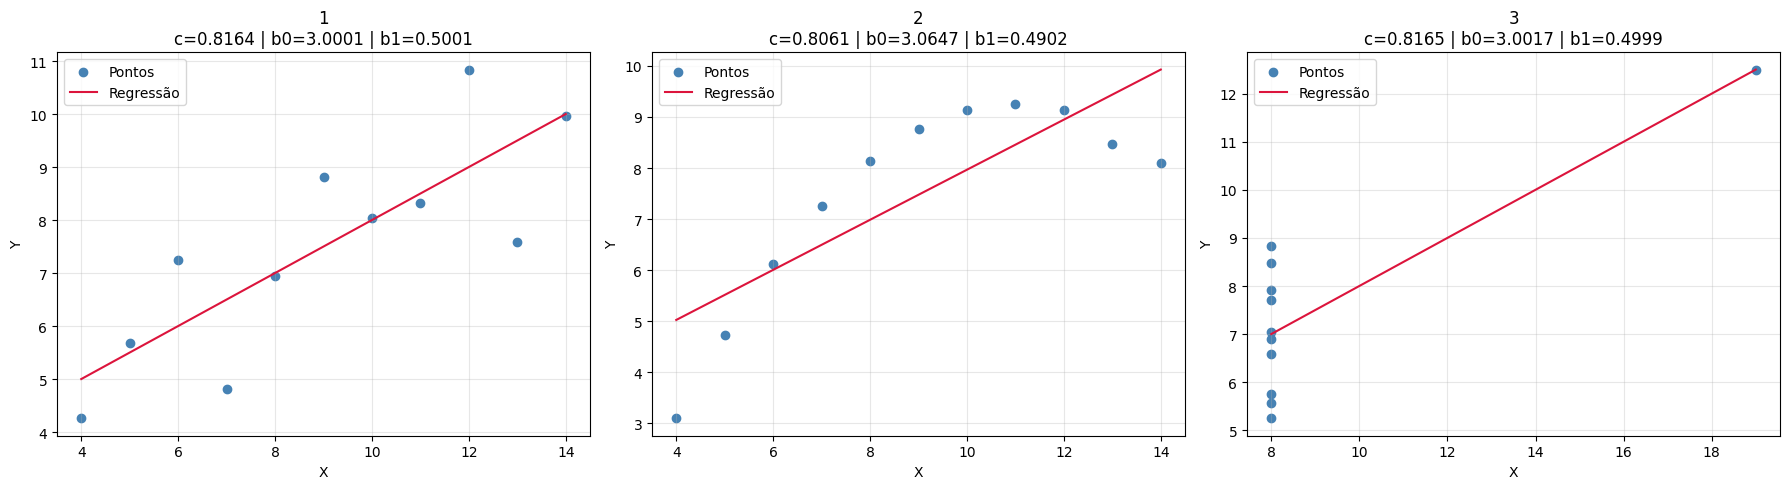

In [82]:
import matplotlib.pyplot as plt

dados = [("1", x1, y1), ("2", x2, y2), ("3", x3, y3)]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (nome, x, y) in zip(axes, dados):
    c = correlacao(x, y)
    b1 = betaUm(x, y)
    b0 = betaZero(x, y, b1)

    ax.scatter(x, y, color="steelblue", label="Pontos")

    x_linha = [min(x), max(x)]
    y_linha = [b0 + b1 * xi for xi in x_linha]
    ax.plot(x_linha, y_linha, color="crimson", label="Regressão")

    ax.set_title(f"{nome}\nc={c:.4f} | b0={b0:.4f} | b1={b1:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

## Trabalho 2

In [83]:
%pip install -q numpy scikit-learn pandas plotly "anywidget>=0.9.13" nbformat


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [84]:
import scipy.io as scipy

mat = scipy.loadmat('data.mat')
data = mat['data']

In [85]:
import pandas as pd

df = pd.DataFrame(data)

df[0] = pd.to_numeric(df[0])
df[1] = pd.to_numeric(df[1])
df[2] = pd.to_numeric(df[2])

In [86]:
# Utilize o comando python .describe()para fazer uma primeira análise estatística da sua base de dados

print("describe: \n", df.describe())

describe: 
                  0          1              2
count    47.000000  47.000000      47.000000
mean   2000.680851   3.170213  340412.659574
std     794.702354   0.760982  125039.899586
min     852.000000   1.000000  169900.000000
25%    1432.000000   3.000000  249900.000000
50%    1888.000000   3.000000  299900.000000
75%    2269.000000   4.000000  384450.000000
max    4478.000000   5.000000  699900.000000


In [87]:
# A primeira coluna é o tamanho da casa, a segunda coluna é o número de quartos, e a terceira coluna é o preço da casa.

# Qual a média de preço das casas? 
print("média: ", df.mean()[2])

# Quanto custa a menor casa? 
menor_tamanho = df.min()[0]
menor_tamanho_valor = df[df[0] == menor_tamanho].values[0][2]

print("menor casa: ", menor_tamanho_valor)

# Quantos quartos tem a casa mais cara?
mais_cara = df.max()[2]
qtd_quartos = df[df[2] == mais_cara].values[0][1]

print("casa mais cara tem x quartos: ", qtd_quartos)

média:  340412.6595744681
menor casa:  179900
casa mais cara tem x quartos:  5


In [88]:
# Gere uma matriz X para as variáveis ​​independentes (que são o tamanho da casa e o número de quartos) 
# e o vetor y da variável dependente (que é o preço).

import numpy as np


preco_y = df[2].values

matrix_x = df[[0, 1]]
matrix_x.insert(0, "adicional", 1)

matrix_x_inversa = np.linalg.inv(matrix_x.values.T.dot(matrix_x.values)).dot(matrix_x.values.T)

betas = matrix_x_inversa.dot(preco_y)

b0 = betas[0]
b1 = betas[1]
b2 = betas[2]

print("betas: ", betas)

print(matrix_x.values)

betas:  [89597.9095428    139.21067402 -8738.01911233]
[[   1 2104    3]
 [   1 1600    3]
 [   1 2400    3]
 [   1 1416    2]
 [   1 3000    4]
 [   1 1985    4]
 [   1 1534    3]
 [   1 1427    3]
 [   1 1380    3]
 [   1 1494    3]
 [   1 1940    4]
 [   1 2000    3]
 [   1 1890    3]
 [   1 4478    5]
 [   1 1268    3]
 [   1 2300    4]
 [   1 1320    2]
 [   1 1236    3]
 [   1 2609    4]
 [   1 3031    4]
 [   1 1767    3]
 [   1 1888    2]
 [   1 1604    3]
 [   1 1962    4]
 [   1 3890    3]
 [   1 1100    3]
 [   1 1458    3]
 [   1 2526    3]
 [   1 2200    3]
 [   1 2637    3]
 [   1 1839    2]
 [   1 1000    1]
 [   1 2040    4]
 [   1 3137    3]
 [   1 1811    4]
 [   1 1437    3]
 [   1 1239    3]
 [   1 2132    4]
 [   1 4215    4]
 [   1 2162    4]
 [   1 1664    2]
 [   1 2238    3]
 [   1 2567    4]
 [   1 1200    3]
 [   1  852    2]
 [   1 1852    4]
 [   1 1203    3]]


Correlação entre tamanho da casa e preço:  0.8549875928781254
Correlação entre número de quartos e preço:  0.44226111704897236


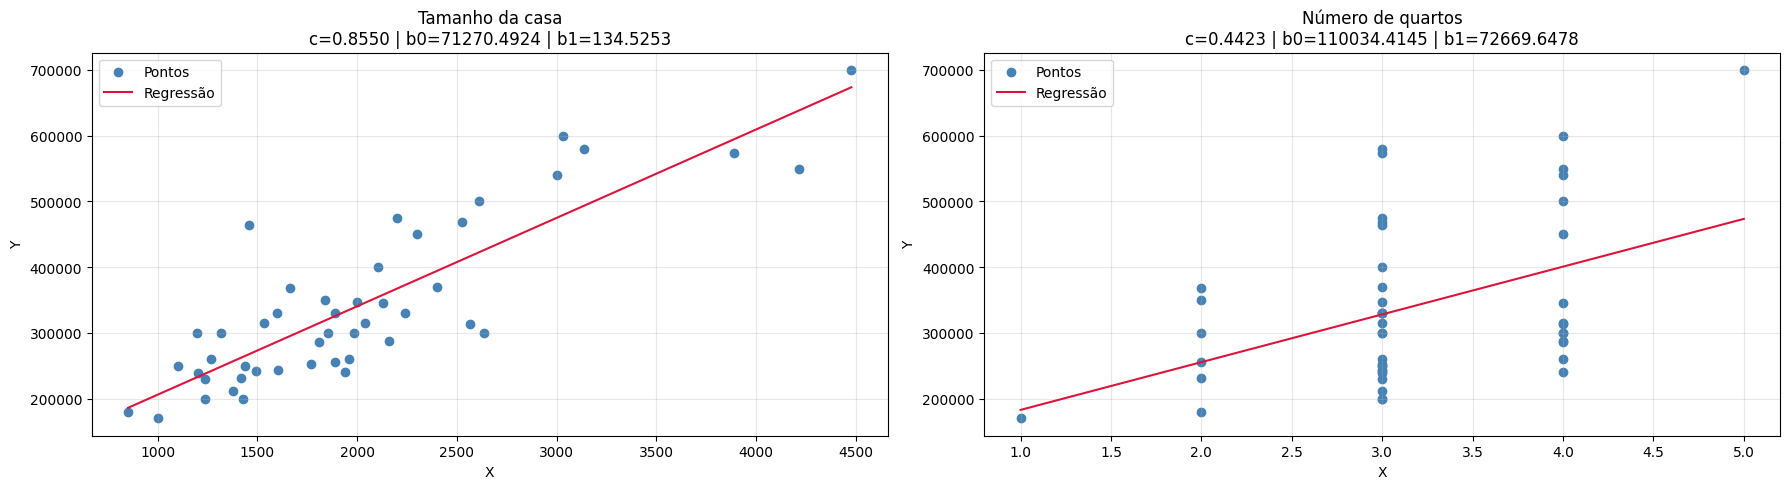

In [89]:
# Verifique a correlação e a regressão para 
# Tamanho da casa e Preço, e Número de quartos e Preço; mostre nos gráficos.

import matplotlib.pyplot as plt

corr_tamanho_preco = correlacao(df[0].values, df[2].values)
corr_quartos_preco = correlacao(df[1].values, df[2].values)

print("Correlação entre tamanho da casa e preço: ", corr_tamanho_preco)
print("Correlação entre número de quartos e preço: ", corr_quartos_preco)

fig, axes = plt.subplots(1, 2, figsize=(18, 5))
dados = [("Tamanho da casa", df[0].values, df[2].values), ("Número de quartos", df[1].values, df[2].values)]

for ax, (nome, x, y) in zip(axes, dados):
    c = correlacao(x, y)
    b1 = betaUm(x, y)
    b0 = betaZero(x, y, b1)

    ax.scatter(x, y, color="steelblue", label="Pontos")

    x_linha = [min(x), max(x)]
    y_linha = [b0 + b1 * xi for xi in x_linha]
    ax.plot(x_linha, y_linha, color="crimson", label="Regressão")

    ax.set_title(f"{nome}\nc={c:.4f} | b0={b0:.4f} | b1={b1:.4f}")
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()
plt.show()

In [106]:
# (e) - cálculo
# Calcule a Regressão Múltipla.

def griz_z_regmultipla(grid_x, grid_y):
    return betas[0] + betas[1] * grid_x + betas[2] * grid_y

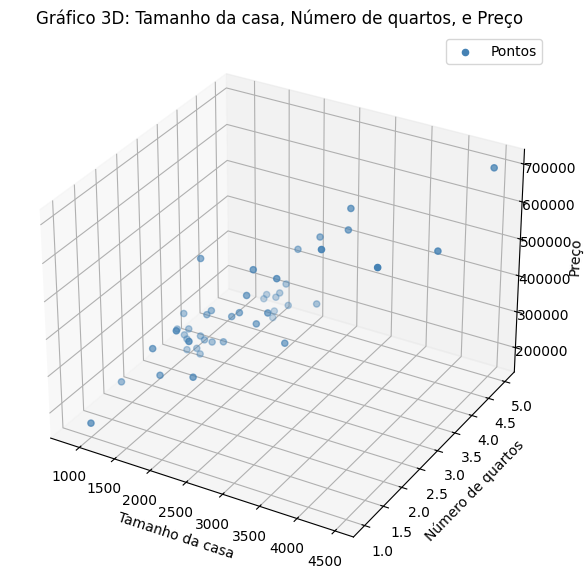

In [91]:

# (e) - gráfico
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")
ax.grid(True, alpha=0.3)
ax.legend()

plt.show()

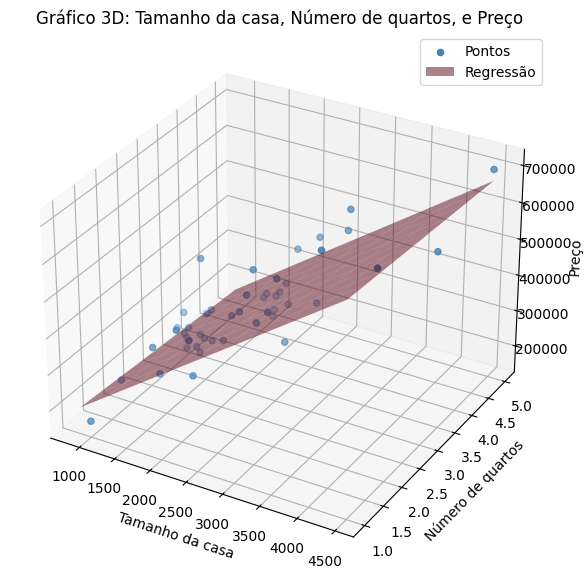

In [107]:
# (f)

import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")

x_range = np.linspace(df[0].min(), df[0].max(), 10)
y_range = np.linspace(df[1].min(), df[1].max(), 10)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = griz_z_regmultipla(x_grid, y_grid)

ax.plot_surface(x_grid, y_grid, z_grid, color='crimson', alpha=0.5, label="Regressão")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()



Coeficiente de correlação entre Tamanho da casa e Preço: 0.85
Coeficiente de correlação entre Número de quartos e Preço: 0.44


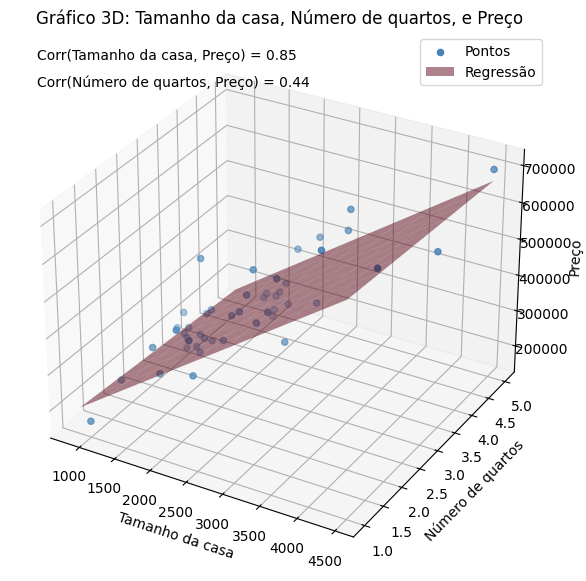

In [108]:
# (g) Mostre na figura os coeficientes de correlação entre Tamanho da casa e Preço e Número de quartos e Preço.

corr_tamanho_preco = df[0].corr(df[2])
corr_quartos_preco = df[1].corr(df[2])

print(f"Coeficiente de correlação entre Tamanho da casa e Preço: {corr_tamanho_preco:.2f}")
print(f"Coeficiente de correlação entre Número de quartos e Preço: {corr_quartos_preco:.2f}")


import numpy as np
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(df[0].values, df[1].values, df[2].values, color="steelblue", label="Pontos")
ax.set_title("Gráfico 3D: Tamanho da casa, Número de quartos, e Preço")
ax.set_xlabel("Tamanho da casa")
ax.set_ylabel("Número de quartos")
ax.set_zlabel("Preço")

x_range = np.linspace(df[0].min(), df[0].max(), 10)
y_range = np.linspace(df[1].min(), df[1].max(), 10)
x_grid, y_grid = np.meshgrid(x_range, y_range)
z_grid = griz_z_regmultipla(x_grid, y_grid)

ax.text2D(0.05, 0.95, f"Corr(Tamanho da casa, Preço) = {corr_tamanho_preco:.2f}", transform=ax.transAxes)
ax.text2D(0.05, 0.90, f"Corr(Número de quartos, Preço) = {corr_quartos_preco:.2f}", transform=ax.transAxes)


ax.plot_surface(x_grid, y_grid, z_grid, color='crimson', alpha=0.5, label="Regressão")
ax.grid(True, alpha=0.3)
ax.legend()



plt.show()


In [94]:
# Calcule o preço de uma casa que tem tamanho de 1650 e 3 quartos. O resultado deve ser igual a 293081. 
# Aumente e diminua a quantidade de número de quartos. O que acontece? Por qual motivo?

tamanho_casa = 1650
num_quartos = 3

valor_aproximado = betas[0] + betas[1] * tamanho_casa + betas[2] * num_quartos

print(f"Preço aproximado para casa com tamanho {tamanho_casa} e {num_quartos} quartos: {valor_aproximado:.0f}")

print("=" * 10)

for i in range(1, 6):
    valor_aproximado = betas[0] + betas[1] * tamanho_casa + (betas[2] * i) # aqui ó, beta 2 negativo
    print(f"Preço aproximado para casa com tamanho {tamanho_casa} e {i} quartos: {valor_aproximado:.0f}")

# o que aconteceu? por qual motivo?
# os preços diminuíram, isso acontece porque o beta 2 é negativo, ou seja, a cada quarto a mais, o preço diminui (constante o tamanho)


Preço aproximado para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado para casa com tamanho 1650 e 1 quartos: 310558
Preço aproximado para casa com tamanho 1650 e 2 quartos: 301819
Preço aproximado para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado para casa com tamanho 1650 e 4 quartos: 284343
Preço aproximado para casa com tamanho 1650 e 5 quartos: 275605


In [95]:
# Compare seus resultados com a função de regressão linear múltipla do python. Para isso você irá precisar das bibliotecas numpy e scikit-learn.

from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(df[[0, 1]], df[2])

print("Coeficientes (sklearn): ", model.coef_)
print("Intercepto (sklearn): ", model.intercept_)

preco_aproximado_sklearn = model.predict([[tamanho_casa, num_quartos]])[0]
print(f"Preço aproximado (sklearn) para casa com tamanho {tamanho_casa} e {num_quartos} quartos: {preco_aproximado_sklearn:.0f}")

print("=" * 10)

for i in range(1, 6):
    preco_aproximado_sklearn = model.predict([[tamanho_casa, i]])[0]
    print(f"Preço aproximado (sklearn) para casa com tamanho {tamanho_casa} e {i} quartos: {preco_aproximado_sklearn:.0f}")

Coeficientes (sklearn):  [  139.21067402 -8738.01911233]
Intercepto (sklearn):  89597.90954279734
Preço aproximado (sklearn) para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado (sklearn) para casa com tamanho 1650 e 1 quartos: 310558
Preço aproximado (sklearn) para casa com tamanho 1650 e 2 quartos: 301819
Preço aproximado (sklearn) para casa com tamanho 1650 e 3 quartos: 293081
Preço aproximado (sklearn) para casa com tamanho 1650 e 4 quartos: 284343
Preço aproximado (sklearn) para casa com tamanho 1650 e 5 quartos: 275605


## Trabalho 3

In [96]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as scipy

# (a) carregando os dados

mat_preg = scipy.loadmat('data_preg.mat')
nome_variavel = next(chave for chave in mat_preg.keys() if not chave.startswith('__'))
dados_preg = np.asarray(mat_preg[nome_variavel], dtype=float)

x_preg = dados_preg[:, 0]
y_preg = dados_preg[:, 1]

print(f"Variavel carregada: {nome_variavel}")
print(f"Formato da base: {dados_preg.shape}")

Variavel carregada: data
Formato da base: (53, 2)


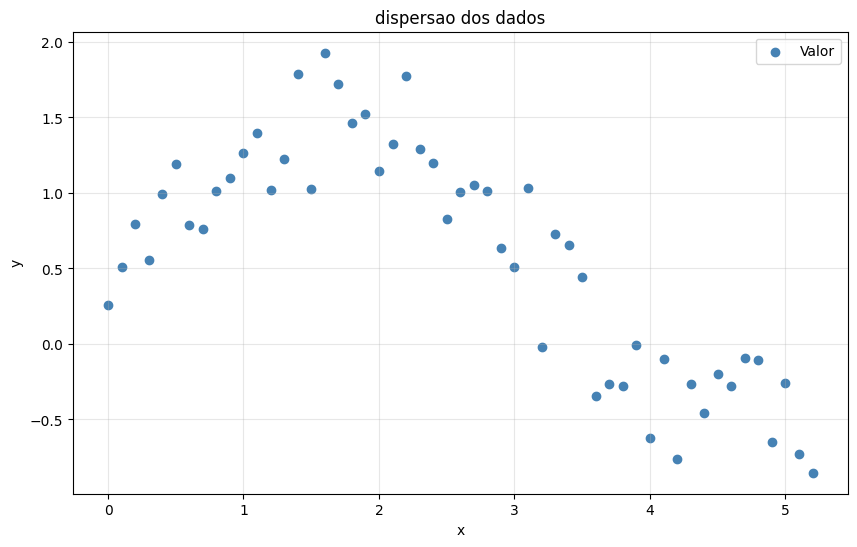

In [97]:
# (b) grafico de dispersao dos dados

plt.figure(figsize=(10, 6))
plt.scatter(x_preg, y_preg, color='steelblue', label='Valor')
plt.title('dispersao dos dados')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

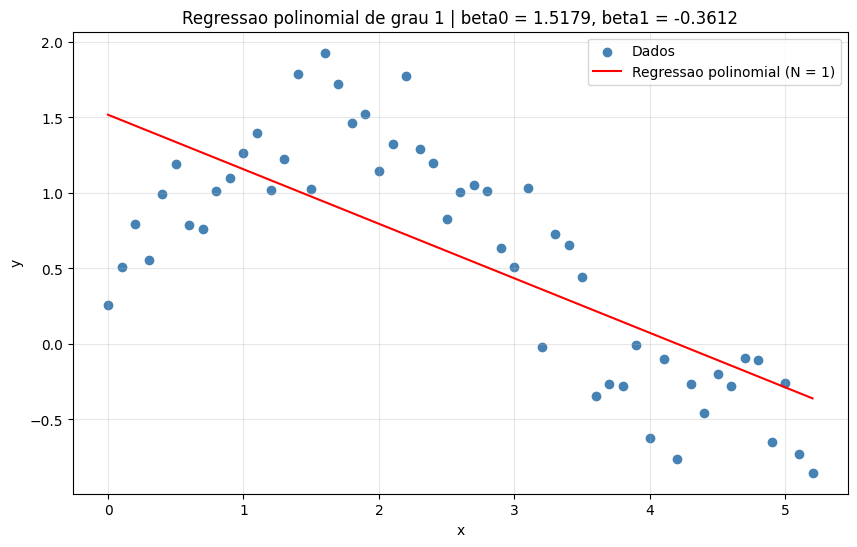

beta1 = -0.361221
beta0 = 1.517857


In [ ]:
# (c)

coeficientes_n1 = np.polyfit(x_preg, y_preg, 1)
beta1_n1 = coeficientes_n1[0]
beta0_n1 = coeficientes_n1[1]

x_linha = np.linspace(x_preg.min(), x_preg.max(), 200) # cria uma lista de numeros intercalados do minimo ao maximo, de 200 em 200
y_linha = np.polyval(coeficientes_n1, x_linha) # calcula o valor de y a partir do modelo criado pelo polyfit

plt.figure(figsize=(10, 6))
plt.scatter(x_preg, y_preg, color='steelblue', label='Dados')
plt.plot(x_linha, y_linha, 'r', label='Regressao polinomial (N = 1)')
plt.title(f'Regressao polinomial de grau 1 | beta0 = {beta0_n1:.4f}, beta1 = {beta1_n1:.4f}')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print(f'beta1 = {beta1_n1:.6f}')
print(f'beta0 = {beta0_n1:.6f}')

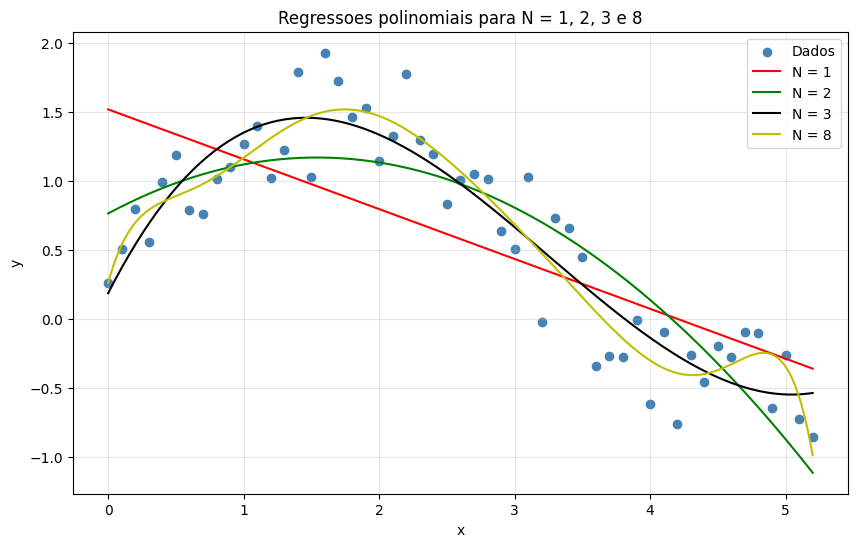

coeficientes N = 2: [-0.1706346   0.5260785   0.76365224]
coeficientes N = 3: [ 0.08715445 -0.8504393   1.9266505   0.18581825]
coeficientes N = 8: [-4.44052475e-03  9.03961597e-02 -7.59536393e-01  3.39079569e+00
 -8.56617903e+00  1.19849000e+01 -8.74036768e+00  3.51030490e+00
  2.61430351e-01]


In [ ]:
# (d), (e) e (f)
# calculando o polinomio na mao, sem usar a funcao pronta de previsao

## mesma coisa que o polyval, mas na "mão"
def calcula_polinomio(coeficientes, valores_x):
    valores_y = []
    grau = len(coeficientes) - 1

    for x in valores_x:
        y = 0
        potencia = grau

        for beta in coeficientes:
            y = y + beta * (x ** potencia)
            potencia = potencia - 1

        valores_y.append(y)

    return np.array(valores_y)

coeficientes_n1 = np.polyfit(x_preg, y_preg, 1)
coeficientes_n2 = np.polyfit(x_preg, y_preg, 2)
coeficientes_n3 = np.polyfit(x_preg, y_preg, 3)
coeficientes_n8 = np.polyfit(x_preg, y_preg, 8)

x_linha = np.linspace(x_preg.min(), x_preg.max(), 200)

y_linha_n1 = calcula_polinomio(coeficientes_n1, x_linha)
y_linha_n2 = calcula_polinomio(coeficientes_n2, x_linha)
y_linha_n3 = calcula_polinomio(coeficientes_n3, x_linha)
y_linha_n8 = calcula_polinomio(coeficientes_n8, x_linha)

plt.figure(figsize=(10, 6))
plt.scatter(x_preg, y_preg, color='steelblue', label='Dados')
plt.plot(x_linha, y_linha_n1, 'r', label='N = 1')
plt.plot(x_linha, y_linha_n2, 'g', label='N = 2')
plt.plot(x_linha, y_linha_n3, 'k', label='N = 3')
plt.plot(x_linha, y_linha_n8, 'y', label='N = 8')
plt.title('Regressoes polinomiais para N = 1, 2, 3 e 8')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('coeficientes N = 2:', coeficientes_n2)
print('coeficientes N = 3:', coeficientes_n3)
print('coeficientes N = 8:', coeficientes_n8)

In [ ]:
# (g) erro quadratico medio

def eqm(y_real, y_previsto):
    return np.mean((y_real - y_previsto) ** 2) 

y_previsto_n1 = calcula_polinomio(coeficientes_n1, x_preg)
y_previsto_n2 = calcula_polinomio(coeficientes_n2, x_preg)
y_previsto_n3 = calcula_polinomio(coeficientes_n3, x_preg)
y_previsto_n8 = calcula_polinomio(coeficientes_n8, x_preg)

eqm_n1 = eqm(y_preg, y_previsto_n1)
eqm_n2 = eqm(y_preg, y_previsto_n2)
eqm_n3 = eqm(y_preg, y_previsto_n3)
eqm_n8 = eqm(y_preg, y_previsto_n8)

print(f'EQM para N = 1: {eqm_n1:.6f}')
print(f'EQM para N = 2: {eqm_n2:.6f}')
print(f'EQM para N = 3: {eqm_n3:.6f}')
print(f'EQM para N = 8: {eqm_n8:.6f}')

eqms = {1: eqm_n1, 2: eqm_n2, 3: eqm_n3, 8: eqm_n8}
grau_mais_preciso = min(eqms, key=eqms.get)

print(f'O polinomio mais preciso foi o de grau {grau_mais_preciso}, pois teve o menor erro quad médio')

EQM para N = 1: 0.265932
EQM para N = 2: 0.138526
EQM para N = 3: 0.078697
EQM para N = 8: 0.058710
O polinomio mais preciso foi o de grau 8, pois teve o menor erro quad médio


seed usada: 42
total de amostras: 53
qtd treino: 47
qtd teste: 6
indices de teste: [ 7 17 27 37 39 52]


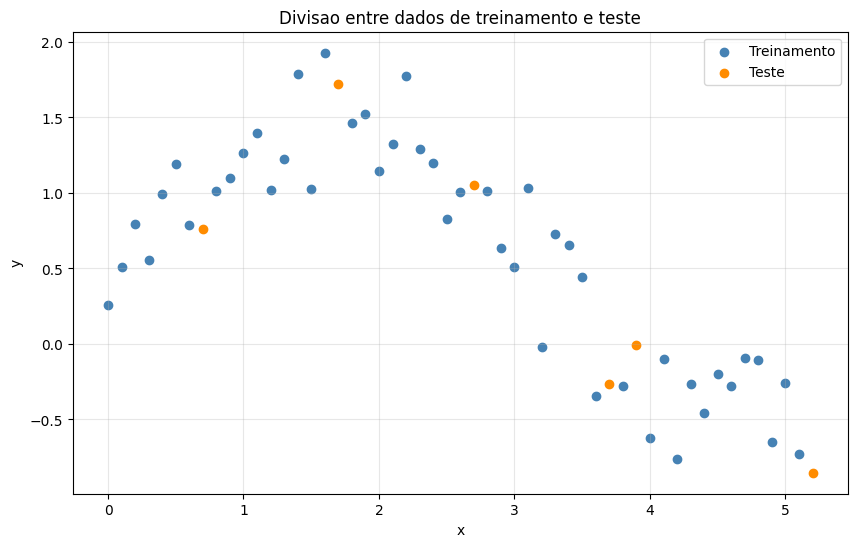

In [101]:
# (h) divisao entre treinamento e teste
# usando seed fixa para sempre cair nos mesmos 10% de teste

seed = 42
gerador = np.random.default_rng(seed)

indices = gerador.permutation(len(x_preg))
qtd_teste = max(1, int(np.ceil(len(x_preg) * 0.1)))

indices_teste = np.sort(indices[:qtd_teste])
indices_treino = np.sort(indices[qtd_teste:])

x_treino = x_preg[indices_treino]
y_treino = y_preg[indices_treino]
x_teste = x_preg[indices_teste]
y_teste = y_preg[indices_teste]

print(f'seed usada: {seed}')
print(f'total de amostras: {len(x_preg)}')
print(f'qtd treino: {len(x_treino)}')
print(f'qtd teste: {len(x_teste)}')
print('indices de teste:', indices_teste)

plt.figure(figsize=(10, 6))
plt.scatter(x_treino, y_treino, color='steelblue', label='Treinamento')
plt.scatter(x_teste, y_teste, color='darkorange', label='Teste')
plt.title('Divisao entre dados de treinamento e teste')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

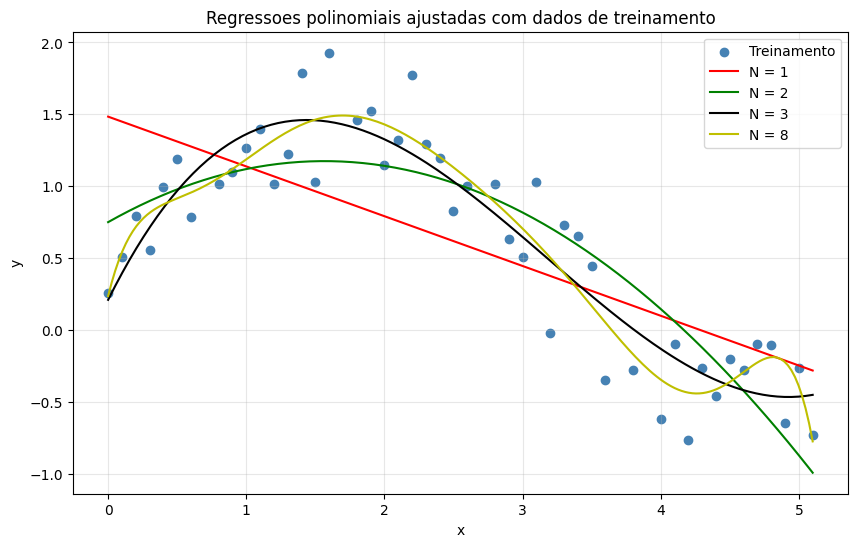

coeficientes treino N = 1: [-0.34603796  1.48412585]
coeficientes treino N = 2: [-0.17329627  0.54226146  0.75073072]
coeficientes treino N = 3: [ 0.0907148  -0.86584237  1.9267884   0.2106557 ]
coeficientes treino N = 8: [-6.04569873e-03  1.19828724e-01 -9.75792313e-01  4.20709032e+00
 -1.02632418e+01  1.39520549e+01 -1.00056434e+01  3.92261034e+00
  2.36270890e-01]


In [102]:
# (i) repetindo c, d, e e f com os dados de treinamento

coeficientes_treino_n1 = np.polyfit(x_treino, y_treino, 1)
coeficientes_treino_n2 = np.polyfit(x_treino, y_treino, 2)
coeficientes_treino_n3 = np.polyfit(x_treino, y_treino, 3)
coeficientes_treino_n8 = np.polyfit(x_treino, y_treino, 8)

x_linha_treino = np.linspace(x_treino.min(), x_treino.max(), 200)

y_linha_treino_n1 = calcula_polinomio(coeficientes_treino_n1, x_linha_treino)
y_linha_treino_n2 = calcula_polinomio(coeficientes_treino_n2, x_linha_treino)
y_linha_treino_n3 = calcula_polinomio(coeficientes_treino_n3, x_linha_treino)
y_linha_treino_n8 = calcula_polinomio(coeficientes_treino_n8, x_linha_treino)

plt.figure(figsize=(10, 6))
plt.scatter(x_treino, y_treino, color='steelblue', label='Treinamento')
plt.plot(x_linha_treino, y_linha_treino_n1, 'r', label='N = 1')
plt.plot(x_linha_treino, y_linha_treino_n2, 'g', label='N = 2')
plt.plot(x_linha_treino, y_linha_treino_n3, 'k', label='N = 3')
plt.plot(x_linha_treino, y_linha_treino_n8, 'y', label='N = 8')
plt.title('Regressoes polinomiais ajustadas com dados de treinamento')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

print('coeficientes treino N = 1:', coeficientes_treino_n1)
print('coeficientes treino N = 2:', coeficientes_treino_n2)
print('coeficientes treino N = 3:', coeficientes_treino_n3)
print('coeficientes treino N = 8:', coeficientes_treino_n8)

In [103]:
# (j) calculando o erro apenas nos dados de teste

y_teste_previsto_n1 = calcula_polinomio(coeficientes_treino_n1, x_teste)
y_teste_previsto_n2 = calcula_polinomio(coeficientes_treino_n2, x_teste)
y_teste_previsto_n3 = calcula_polinomio(coeficientes_treino_n3, x_teste)
y_teste_previsto_n8 = calcula_polinomio(coeficientes_treino_n8, x_teste)

eqm_teste_n1 = eqm(y_teste, y_teste_previsto_n1)
eqm_teste_n2 = eqm(y_teste, y_teste_previsto_n2)
eqm_teste_n3 = eqm(y_teste, y_teste_previsto_n3)
eqm_teste_n8 = eqm(y_teste, y_teste_previsto_n8)

print(f'erro para N = 1: {eqm_teste_n1:.6f}')
print(f'erro para N = 2: {eqm_teste_n2:.6f}')
print(f'erro para N = 3: {eqm_teste_n3:.6f}')
print(f'erro para N = 8: {eqm_teste_n8:.6f}')

eqms_teste = {1: eqm_teste_n1, 2: eqm_teste_n2, 3: eqm_teste_n3, 8: eqm_teste_n8}
grau_mais_preciso_teste = min(eqms_teste, key=eqms_teste.get)

print(f'No conjunto de teste, o polinomio mais preciso foi o de grau {grau_mais_preciso_teste}, pois teve o menor erro quadratico medio.')

erro para N = 1: 0.282786
erro para N = 2: 0.157444
erro para N = 3: 0.097121
erro para N = 8: 0.103210
No conjunto de teste, o polinomio mais preciso foi o de grau 3, pois teve o menor erro quadratico medio.


In [104]:
# (k) coeficiente de determinacao R2
# (l) conclusao sobre o modelo mais preciso

from sklearn.metrics import r2_score

r2_treino_n1 = r2_score(y_treino, calcula_polinomio(coeficientes_treino_n1, x_treino))
r2_treino_n2 = r2_score(y_treino, calcula_polinomio(coeficientes_treino_n2, x_treino))
r2_treino_n3 = r2_score(y_treino, calcula_polinomio(coeficientes_treino_n3, x_treino))
r2_treino_n8 = r2_score(y_treino, calcula_polinomio(coeficientes_treino_n8, x_treino))

r2_teste_n1 = r2_score(y_teste, calcula_polinomio(coeficientes_treino_n1, x_teste))
r2_teste_n2 = r2_score(y_teste, calcula_polinomio(coeficientes_treino_n2, x_teste))
r2_teste_n3 = r2_score(y_teste, calcula_polinomio(coeficientes_treino_n3, x_teste))
r2_teste_n8 = r2_score(y_teste, calcula_polinomio(coeficientes_treino_n8, x_teste))

print(f'r2 para N = 1: {r2_treino_n1:.6f}')
print(f'r2 para N = 2: {r2_treino_n2:.6f}')
print(f'r2 para N = 3: {r2_treino_n3:.6f}')
print(f'r2 para N = 8: {r2_treino_n8:.6f}')

print('=' * 10)

print(f'r2 para N = 1: {r2_teste_n1:.6f}')
print(f'r2 para N = 2: {r2_teste_n2:.6f}')
print(f'r2 para N = 3: {r2_teste_n3:.6f}')
print(f'r2 para N = 8: {r2_teste_n8:.6f}')

r2s_teste = {1: r2_teste_n1, 2: r2_teste_n2, 3: r2_teste_n3, 8: r2_teste_n8}
melhor_r2_teste = max(r2s_teste, key=r2s_teste.get)

print('=' * 10)
print(f'melhor r2 no teste: grau {melhor_r2_teste}')
print(f'melhor eqm no teste: grau {grau_mais_preciso_teste}')

if melhor_r2_teste == grau_mais_preciso_teste:
    print(f'neste caso, o grau {grau_mais_preciso_teste} foi o mais preciso, porque teve menor eqm e maior r2 no teste.')
else:
    print('os criterios de eqm e r2 apontaram modelos diferentes no teste, entao vale analisar os dois resultados com cuidado')

print('quanto mais perto de 1 estiver o R2, melhor o modelo explica a variacao dos dados.')
print('se o R2 no treino for muito alto e no teste cair bastante, isso indica overfitting.')

r2 para N = 1: 0.514109
r2 para N = 2: 0.749751
r2 para N = 3: 0.857538
r2 para N = 8: 0.889741
r2 para N = 1: 0.621715
r2 para N = 2: 0.789387
r2 para N = 3: 0.870080
r2 para N = 8: 0.861936
melhor r2 no teste: grau 3
melhor eqm no teste: grau 3
neste caso, o grau 3 foi o mais preciso, porque teve menor eqm e maior r2 no teste.
quanto mais perto de 1 estiver o R2, melhor o modelo explica a variacao dos dados.
se o R2 no treino for muito alto e no teste cair bastante, isso indica overfitting.


/tmp/ipykernel_2224/1708581942.py:3: RankWarning: Polyfit may be poorly conditioned
  coeficientes_treino_n20 = np.polyfit(x_treino, y_treino, 20)


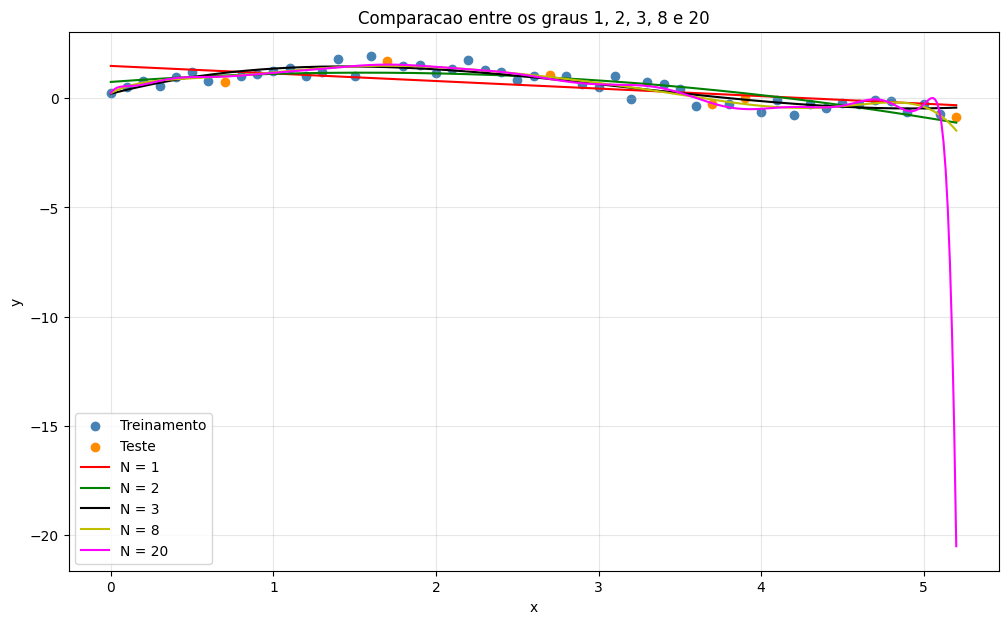

eqm para N = 1: 0.264426
eqm para N = 2: 0.136188
eqm para N = 3: 0.077529
eqm para N = 8: 0.060004
eqm para N = 20: 0.051458
eqm para N = 1: 0.282786
eqm para N = 2: 0.157444
eqm para N = 3: 0.097121
eqm para N = 8: 0.103210
eqm para N = 20: 64.555079
r2 treino para N = 20: 0.905444
r2 teste para N = 20: -85.355812
melhor grau no teste considerando tambem o grau 20: 3
o grau 20 nao apresentou o menor eqm no teste nesta divisao dos dados.
a curva de grau 20 tende a ficar bem mais ondulada e sensivel aos pontos de treinamento.
quando o erro de treino cai muito e o erro de teste nao melhora, isso indica overfitting.


In [105]:
# (m) regressao polinomial de grau 20

coeficientes_treino_n20 = np.polyfit(x_treino, y_treino, 20)

x_linha_geral = np.linspace(x_preg.min(), x_preg.max(), 400)

y_linha_geral_n1 = calcula_polinomio(coeficientes_treino_n1, x_linha_geral)
y_linha_geral_n2 = calcula_polinomio(coeficientes_treino_n2, x_linha_geral)
y_linha_geral_n3 = calcula_polinomio(coeficientes_treino_n3, x_linha_geral)
y_linha_geral_n8 = calcula_polinomio(coeficientes_treino_n8, x_linha_geral)
y_linha_geral_n20 = calcula_polinomio(coeficientes_treino_n20, x_linha_geral)

plt.figure(figsize=(12, 7))
plt.scatter(x_treino, y_treino, color='steelblue', label='Treinamento')
plt.scatter(x_teste, y_teste, color='darkorange', label='Teste')
plt.plot(x_linha_geral, y_linha_geral_n1, 'r', label='N = 1')
plt.plot(x_linha_geral, y_linha_geral_n2, 'g', label='N = 2')
plt.plot(x_linha_geral, y_linha_geral_n3, 'k', label='N = 3')
plt.plot(x_linha_geral, y_linha_geral_n8, 'y', label='N = 8')
plt.plot(x_linha_geral, y_linha_geral_n20, color='magenta', label='N = 20')
plt.title('Comparacao entre os graus 1, 2, 3, 8 e 20')
plt.xlabel('x')
plt.ylabel('y')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

eqm_treino_n20 = eqm(y_treino, calcula_polinomio(coeficientes_treino_n20, x_treino))
eqm_teste_n20 = eqm(y_teste, calcula_polinomio(coeficientes_treino_n20, x_teste))
r2_treino_n20 = r2_score(y_treino, calcula_polinomio(coeficientes_treino_n20, x_treino))
r2_teste_n20 = r2_score(y_teste, calcula_polinomio(coeficientes_treino_n20, x_teste))

print(f'eqm para N = 1: {eqm(y_treino, calcula_polinomio(coeficientes_treino_n1, x_treino)):.6f}')
print(f'eqm para N = 2: {eqm(y_treino, calcula_polinomio(coeficientes_treino_n2, x_treino)):.6f}')
print(f'eqm para N = 3: {eqm(y_treino, calcula_polinomio(coeficientes_treino_n3, x_treino)):.6f}')
print(f'eqm para N = 8: {eqm(y_treino, calcula_polinomio(coeficientes_treino_n8, x_treino)):.6f}')
print(f'eqm para N = 20: {eqm_treino_n20:.6f}')

print('=' * 10)

print(f'eqm para N = 1: {eqm_teste_n1:.6f}')
print(f'eqm para N = 2: {eqm_teste_n2:.6f}')
print(f'eqm para N = 3: {eqm_teste_n3:.6f}')
print(f'eqm para N = 8: {eqm_teste_n8:.6f}')
print(f'eqm para N = 20: {eqm_teste_n20:.6f}')

print('=' * 10)

print(f'r2 treino para N = 20: {r2_treino_n20:.6f}')
print(f'r2 teste para N = 20: {r2_teste_n20:.6f}')

eqms_teste_com_n20 = {1: eqm_teste_n1, 2: eqm_teste_n2, 3: eqm_teste_n3, 8: eqm_teste_n8, 20: eqm_teste_n20}
melhor_grau_teste_com_n20 = min(eqms_teste_com_n20, key=eqms_teste_com_n20.get)

print('=' * 10)
print(f'melhor grau no teste considerando tambem o grau 20: {melhor_grau_teste_com_n20}')

if melhor_grau_teste_com_n20 == 20:
    print('o grau 20 apresentou o menor eqm no teste nesta divisao dos dados.')
else:
    print('o grau 20 nao apresentou o menor eqm no teste nesta divisao dos dados.')

print('a curva de grau 20 tende a ficar bem mais ondulada e sensivel aos pontos de treinamento.')
print('quando o erro de treino cai muito e o erro de teste nao melhora, isso indica overfitting.')